# Modélisation du risque en assurance non-vie avec le modèle Cramér-Lundberg


## Introduction

L’évaluation du risque est un enjeu central en assurance, où la fréquence et le coût des sinistres sont par nature incertains. Les assureurs doivent ainsi être en mesure d’anticiper ces aléas afin de garantir leur solvabilité et d’adapter leur politique de tarification. Pour cela, des modèles probabilistes sont utilisés afin de représenter de manière réaliste l’apparition et l’impact financier des sinistres.

Dans ce cadre, le modèle de Cramér–Lundberg constitue une approche classique permettant de décrire l’évolution de la réserve d’un assureur au cours du temps. Il offre un cadre simple pour analyser le risque de ruine, c’est-à-dire la probabilité que la réserve devienne négative.

L’objectif de ce projet est d’étudier ce modèle à la fois d’un point de vue théorique et expérimental. Une approche par simulation de Monte Carlo sera mise en œuvre afin d’estimer la probabilité de ruine et d’analyser l’influence des différents paramètres. Une extension du modèle intégrant un facteur d’actualisation sera également considérée afin de prendre en compte la dimension temporelle des flux financiers.

Enfin, l’analyse sera complétée par l’étude de la Value at Risk (VaR), qui permet d’évaluer l’ampleur potentielle des pertes et d’apporter une vision complémentaire du risque.

## Sommaire

### I. Description du projet et analyse théorique
1. Objectif de l'étude 
2. Présentation du modèle  
3. Risques étudiés
4. Résultats théoriques  

### II. Modélisation et analyse expérimentale
1. Modélisation du processus aléatoire  
2. Méthode de monte Carlo pour estimer la probabilité de ruine
3. Impact du capital initial sur le modèle  

### III. Ouverture et approfondissement
1. Modèle alternatif : Modèle de Cramér–Lundberg avec actualisation  
2. Mesure du risque : Value at Risk (VaR)  

### IV. Conclusion

## I. Description du projet et analyse théorique

### 1. Objectif de l'étude

Dans le domaine de l’assurance, il est essentiel de pouvoir évaluer le risque associé aux sinistres. En effet, ni la date d’apparition ni le montant des sinistres ne sont connus à l’avance. Afin de modéliser ces incertitudes, une approche probabiliste est adoptée : les sinistres sont considérés comme des événements aléatoires dont on cherche à quantifier l’impact sur la réserve de l’assureur.

L’objectif de cette étude est d’analyser un modèle probabiliste permettant d’estimer ce risque. Les paramètres du modèle peuvent être ajustés afin de représenter au mieux les données observées et les caractéristiques réelles du portefeuille d’assurance.

---

### 2. Présentation du modèle de Cramér–Lundberg

L’étude repose sur le modèle de Cramér–Lundberg, qui décrit l’évolution de la réserve d’une compagnie d’assurance au cours du temps. Ce modèle prend en compte deux flux financiers opposés :

- un flux entrant, constitué des cotisations versées par les assurés,
- un flux sortant, lié au paiement des sinistres.

La réserve à la date $t$ est donnée par :

$$
R(t) = u + pt - \sum_{i=1}^{N_t} Y_i
$$

où :
- $u$ est le capital initial (ou prime initiale),
- $p$ est le taux de cotisation,
- $N_t$ est un processus de Poisson d’intensité $\mu$, représentant le nombre de sinistres survenus jusqu’au temps $t$,
- $Y_i$ sont des variables aléatoires positives, indépendantes et identiquement distribuées, représentant les montants des sinistres.

---

### 3. Risques étudiés
### 3.1 La probabilité de ruine

Le risque principal étudié est le **risque de ruine**, qui correspond à la probabilité que la réserve devienne négative sur un intervalle de temps donné $[0, T]$.

Pour simplifier l’analyse, nous considérons une approximation de ce risque en étudiant la probabilité que la réserve à la date finale $T$ soit négative :

$$
\mathbb{P}(R(T) < 0)
$$

Dans ce cadre, la survenance de la ruine peut être modélisée comme une variable de Bernoulli, et l’objectif est d’estimer cette probabilité à l’aide de méthodes de simulation de type Monte Carlo.



### 3.2 Extension de l’analyse : Value at Risk

Dans un second temps, l’étude est étendue à l’analyse de la **Value at Risk (VaR)**. Cette mesure permet d’évaluer l’ampleur des pertes extrêmes en estimant, pour un niveau de probabilité donné, le seuil de perte susceptible d’être dépassé. Elle offre ainsi une vision complémentaire du risque, en quantifiant non seulement la probabilité de ruine, mais également la gravité potentielle des pertes.

---

### 4. Résultats théoriques


### Espérance de la réserve

On s’intéresse à l’évolution de l’espérance de la réserve $R(t)$ au cours du temps. En utilisant le théorème de Wald, on obtient :

$$
\mathbb{E}\left[\sum_{i=1}^{N_t} Y_i\right] = \mathbb{E}[N_t] \cdot \mathbb{E}[Y_i]
$$

Or, pour un processus de Poisson :

$$
\mathbb{E}[N_t] = \mu t
$$

Ainsi, l’espérance de la réserve s’écrit :

$$
\mathbb{E}[R(t)] = u + pt - \mu t \, m
$$

soit encore :

$$
\mathbb{E}[R(t)] = u + (p - \mu m)t
$$

---

### Condition de rentabilité

La réserve $R(t)$ représentant la fortune de l’assureur, il est naturel d’imposer que son espérance ne devienne pas négative au cours du temps. On cherche donc une condition assurant :

$$
\mathbb{E}[R(t)] \geq 0 \quad \forall t \geq 0
$$

Comme $\mathbb{E}[R(t)]$ est une fonction affine en $t$, cette condition est équivalente à :

$$
p - \mu m \geq 0
$$

soit :

$$
p \geq \mu m
$$

Cette condition signifie que le taux de cotisation doit être au moins égal au coût moyen des sinistres par unité de temps.

On remarque que cette condition ne dépend pas du capital initial $u$.

---

### Chargement de sécurité

Dans la suite, on choisira un taux de cotisation strictement supérieur à ce seuil minimal. On introduit pour cela un coefficient de sécurité $\theta > 0$ tel que :

$$
p = (1 + \theta) \, \mu m
$$

Ce paramètre $\theta$ permet de modéliser une marge de sécurité de l’assureur, et pourra être ajusté afin d’étudier son impact sur le risque de ruine.

## II. Modélisation et analyse expérimentale
### 1. Modélisation du processus aléatoire  


In [ ]:
from scipy.stats import poisson,expon
import numpy as np
import matplotlib.pyplot as plt



### Simulation de la réserve à l’horizon $T$

Afin de simuler la variable $R(T)$ (notée $R_T$), on procède de la manière suivante :

- Simulation d’une réalisation de la variable $N_T$, où $N_T$ suit une loi de Poisson de paramètre $\mu T$. On note cette réalisation $n_T$.

- Simulation de $n_T$ variables aléatoires indépendantes et identiquement distribuées suivant une loi exponentielle de moyenne $\beta$, représentant les montants des sinistres.

- Calcul de la réserve finale $R_T$ à l’aide de la formule :
  
$$
R_T = u + pT - \sum_{i=1}^{n_T} Y_i
$$

[105]
190.88170579206508


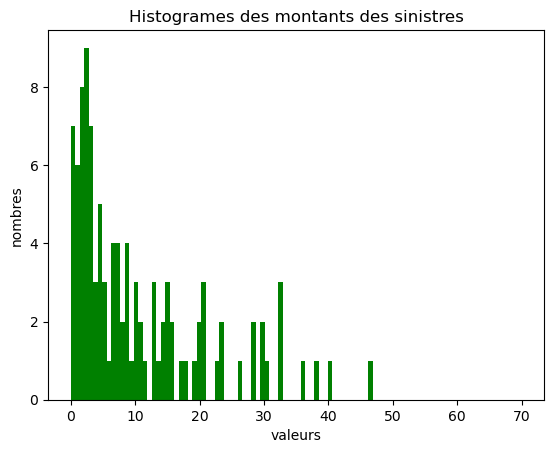

In [89]:
#Paramètres
T=100
mu=1
Beta=0.1
m=1/Beta # m est la moyenne des lois exponentielles
teta=0.3 #teta 0.3 avant 
p_limit=mu*m
p=(1+teta)*p_limit

#Paramètre u va bouger par la suite
u=10
#Simulation de N_T suivant un processus de poissson
#N_*T suis une loi de poisson de paramètre mu*T
N_T = np.random.poisson(mu*T,1)
print(N_T)
#Simulation de N_T lois exponentielles
Y=np.random.exponential(1/Beta,N_T)
plt.hist(Y, range = (0, 70), bins = 100, color = 'green')
plt.xlabel('valeurs')
plt.ylabel('nombres')
plt.title('Histogrames des montants des sinistres')

#Calcul de Rt
R_T=u+p*T - np.sum(Y)
print(R_T)
#Estimation de la probabilité de ruine par répétition de l'algorithme

### Analyse de la distribution des sinistres

Le graphique représente l’histogramme des montants des sinistres simulés. Le choix d’une loi exponentielle apparaît cohérent dans ce contexte.

En effet, on observe que les montants des sinistres sont strictement positifs et que leur fréquence décroît lorsque leur valeur augmente. Les sinistres de faible montant sont donc fréquents, tandis que les sinistres de grande ampleur sont plus rares, mais restent possibles et peuvent engendrer des pertes importantes pour l’assureur.

Afin de se prémunir contre ces risques extrêmes, les contrats d’assurance peuvent prévoir des mécanismes de plafonnement des indemnités. À l’inverse, une fréquence élevée de petits sinistres peut également conduire à un coût total significatif.

Pour limiter l’impact de ces sinistres de faible montant mais fréquents, les assureurs mettent souvent en place une **franchise**, correspondant à la part du sinistre restant à la charge de l’assuré avant toute indemnisation.

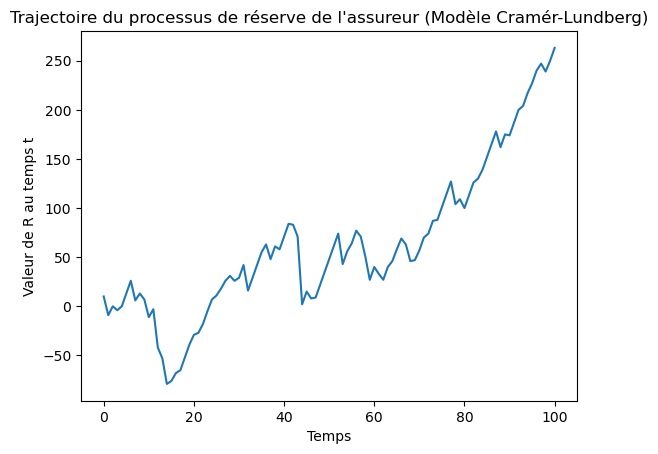

In [ ]:
np.random.seed(0)
u=10
N_T=np.random.poisson(mu*T)
U = np.random.uniform(0,T,N_T)
Arrival_Times = np.sort(U)
Y=np.random.exponential(1/Beta,N_T)
t_range= np.arange(T+1)
R=np.zeros_like(t_range)

for t in t_range:
    R[t]= u +p*t -np.sum(Y[Arrival_Times<t])
plt.xlabel('Temps')
plt.ylabel('Valeur de R au temps t')
plt.title("Trajectoire du processus de réserve de l'assureur (Modèle Cramér-Lundberg)")
plt.plot(t_range,R)
plt.show()

### Analyse d’une trajectoire du processus de réserve

Le graphique représente une simulation du processus de réserve de l’assureur, c’est-à-dire une réalisation du processus décrit par le modèle de Cramér–Lundberg sur l’intervalle de temps $[0, T]$, avec ici $T = 100$.

On observe l’évolution de la réserve au cours du temps, caractérisée par une croissance linéaire liée aux primes, entrecoupée de sauts correspondant aux sinistres.

---

### Remarque

Cette simulation met en évidence une limite de l’approche consistant à étudier uniquement la variable $R(T)$. En effet, le processus peut devenir négatif à certains instants avant $T$, sans que cela ne soit visible en ne considérant que la valeur finale.

Ainsi, une analyse basée uniquement sur $R(T)$ peut sous-estimer le risque de ruine réel. Une approche plus rigoureuse consisterait à étudier la probabilité de ruine sur l’ensemble de l’intervalle $[0, T]$, c’est-à-dire la probabilité que le processus devienne négatif à un instant quelconque.

A partir de maintenant tous les paramètres sont fixés  et nous n'analisons que l'impacte de la variable u

### 6. Méthode de monte Carlo pour estimer la probabilité de ruine

In [120]:
def Simulation(size_MC=50000,graph=True,m=0):
    #Simule avec u = 0, il suffit d'ajouter u après
    u=0
    N_T = np.random.poisson(mu*T,size_MC)
    R_T=np.array([])
    for n in N_T:
        Y=np.random.exponential(1/Beta,n)
        r_T=u+p*T - np.sum(Y)
        R_T=np.append(R_T,r_T)
    if graph:
        plt.hist(R_T, range = (np.min(R_T), np.max(R_T)), bins = 100, color = 'green')
        plt.xlabel('valeurs')
        plt.ylabel('nombres')
        plt.title('Histogramme, Valeurs de R au temps T ')
    
    return R_T
    

def Monte_Carlo(Liste_R_T, u,m=10,write=True):
    Liste_R_T = u +Liste_R_T
    p_estimate = sum(Liste_R_T<-m)/len(Liste_R_T)
    if write : 
        print("u = "+ str(u) +  " m = "+ str(m) +   " p_ruin = " + str(p_estimate))
    return u,p_estimate
    

u = 10 m = 10 p_ruin = 0.01588


(10, np.float64(0.01588))

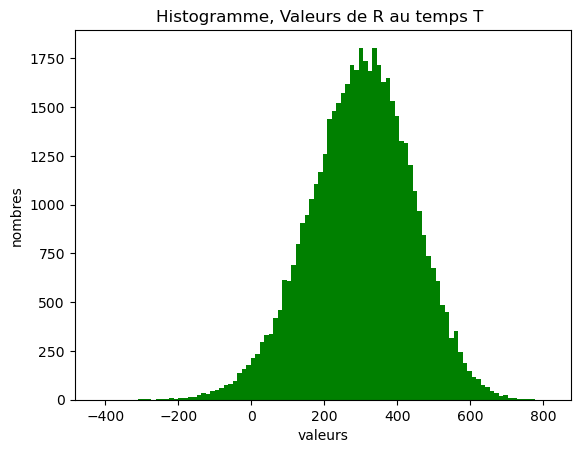

In [121]:
Liste_R_T = Simulation()

Monte_Carlo(Liste_R_T,  10)

#Convergence de monte carlo en 1/sqrt(n) n nombre de simulations

Ce graphique représente l'histogramme des valeurs de R au temps T. Nous nous servirons de ces réalisions pour estimer la probabilité de ruine. En effet, affin d'estimer la probabilité de ruine nous opérons le ratio nombre de réalisations négatives / nombre de réalisations totales

### 3. Impact du capital initial sur le modèle  

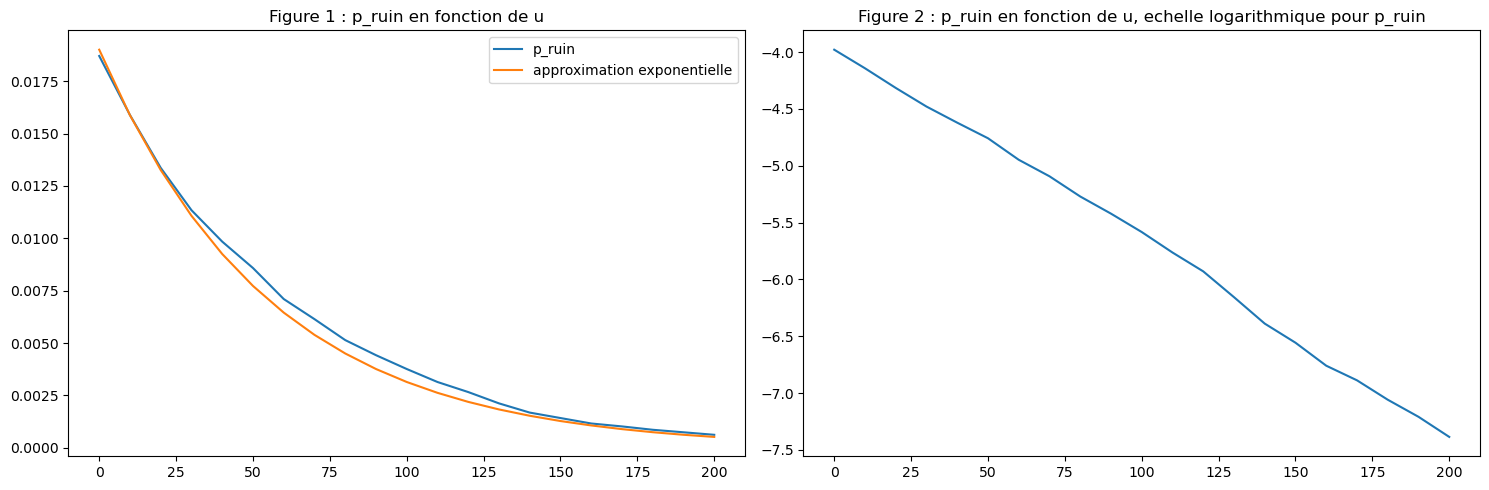

In [ ]:
u_tab=np.array([])
p_ruin_tab=np.array([])

for i in range(0,21):
    u,p_ruin = Monte_Carlo(Liste_R_T,10*i,write = False)
    u_tab=np.append(u_tab,u)
    p_ruin_tab=np.append(p_ruin_tab,p_ruin)



fig, (ax1, ax2) = plt.subplots(1,2,figsize=(15,5))

ax1.plot(u_tab,p_ruin_tab,label="p_ruin")

kapa=0.018
exp_curv=0.019*np.exp(-kapa*u_tab)
ax1.plot(u_tab,exp_curv,label="approximation exponentielle")
ax1.set_title("Figure 1 : p_ruin en fonction de u")
ax1.legend()

ax2.plot(u_tab,np.log(p_ruin_tab))

ax2.set_title("Figure 2 : p_ruin en fonction de u, echelle logarithmique pour p_ruin")

plt.tight_layout()
plt.show()



### Analyse de la probabilité de ruine en fonction du capital initial

La probabilité de ruine décroît en fonction du capital initial $u$, comme l’illustre la courbe orange de la Figure 1. Afin de mieux caractériser cette décroissance, nous avons ajusté les valeurs empiriques de $p_{\text{ruin}}(u)$ à l’aide d’une fonction exponentielle.

Les paramètres de cet ajustement ont été estimés en utilisant une transformation logarithmique, représentée sur la Figure 2. En effet, en prenant le logarithme, la relation devient linéaire, ce qui permet d’identifier le coefficient directeur comme étant $-\kappa$.

On obtient ainsi une approximation de la forme :

$$
p_{\text{ruin}}(u) \approx 0.019 \, e^{-0.018 u}
$$

Cette relation met en évidence que l’influence du capital initial est particulièrement forte pour les faibles valeurs de $u$, puis diminue progressivement.

---

### Interprétation

Dans une perspective de gestion du risque, cette approximation permet de déterminer le capital initial nécessaire pour atteindre un niveau de risque cible. En inversant la relation précédente, on obtient :

$$
u = \frac{\ln\left(\frac{p}{0.019}\right)}{-0.018}
$$

Ainsi, pour une probabilité de ruine fixée $p$, il est possible d’estimer une valeur de $u$ permettant de respecter ce niveau de risque.

## III. Ouverture et approfondissement
### 1. Modèle alternatif : Modèle de Cramér–Lundberg avec actualisation




Dans une version plus complête du modèle, on introduit un facteur d’actualisation afin de tenir compte de la valeur temporelle de l’argent.

La réserve actualisée à la date $t$ s’écrit alors :

$$
R(t) = u + pt - \sum_{i=1}^{N_t} e^{-\rho (t - T_i)} Y_i
$$

où :
- $\rho > 0$ est le taux d’actualisation,
- $T_i$ est la date d’occurrence du $i$-ème sinistre.

---

### Interprétation du facteur d’actualisation

Le terme $e^{-\rho (t - T_i)}$ représente la valeur actualisée du sinistre $Y_i$ à la date $t$.

Ainsi :
- un sinistre récent (avec $T_i$ proche de $t$) a un poids proche de sa valeur réelle,
- un sinistre ancien (avec $T_i$ éloigné de $t$) est “atténué” par l’actualisation.

Ce mécanisme reflète le fait que l'argent perd de la valeur avec le temps

---

### Intérêt du modèle avec actualisation

L’introduction du facteur d’actualisation permet d’exprimer l’ensemble des sinistres en **valeur équivalente à une même date de référence** (par exemple la date finale $T$).
On obtient une vision plus pertinente du risque en termes économiques, en comparant tous les flux (primes et sinistres) à une même date.

### Cas particulier

Lorsque $\rho = 0$, on retrouve le modèle classique :

$$
R(t) = u + pt - \sum_{i=1}^{N_t} Y_i
$$

ce qui correspond à l’absence d’actualisation.

### Espérance du modèle avec actualisation
On s'intéresse à l'espérance de R(T).

### Utilisation de la formule de Campbell

Pour calculer l’espérance de la somme aléatoire, on utilise la **formule de Campbell** pour les processus de Poisson :

$$
\mathbb{E}\left[\sum_{i=1}^{N_T} f(T_i, Y_i)\right]
=
\mu \int_0^T \mathbb{E}[f(t, Y_1)] \, dt
$$

On applique cette formule avec :

$$
f(t, y) = e^{-\rho (T - t)} y
$$

On obtient alors :

$$
\mathbb{E}\left[\sum_{i=1}^{N_T} e^{-\rho (T - T_i)} Y_i\right]
=
\mu \int_0^T \mathbb{E}\left[e^{-\rho (T - t)} Y_1\right] dt
$$

En supposant l’indépendance entre $Y_1$ et $T_i$, on a :

$$
= \mu \, \mathbb{E}[Y_1] \int_0^T e^{-\rho (T - t)} dt
= \mu m \int_0^T e^{-\rho (T - t)} dt
$$

---

### Calcul de l’intégrale

En posant $s = T - t$, on obtient :

$$
\int_0^T e^{-\rho (T - t)} dt
=
\int_0^T e^{-\rho s} ds
=
\frac{1 - e^{-\rho T}}{\rho}
$$

Ainsi :

$$
\mathbb{E}\left[\sum_{i=1}^{N_T} e^{-\rho (T - T_i)} Y_i\right]
=
\mu m \frac{1 - e^{-\rho T}}{\rho}
$$

---

### Espérance de la réserve

On en déduit :

$$
\mathbb{E}[R_T]
=
u + pT - \mu m \frac{1 - e^{-\rho T}}{\rho}
$$

Dans le cas particulier $\rho = 0$, on retrouve par passage à la limite :

$$
\mathbb{E}[R_T] = u + (p - \mu m)T
$$

---

### Condition suffisante pour une espérance positive

Dans le modèle classique (sans actualisation), la condition

$$
p > \mu m
$$

garantit que l’espérance de la réserve est positive.

Dans le modèle avec actualisation, les sinistres sont pondérés par le facteur $e^{-\rho (T - T_i)}$, qui est toujours inférieur ou égal à 1. Ainsi, chaque sinistre a un impact moyen plus faible que dans le modèle classique.

Par conséquent, le terme moyen des sinistres dans le modèle actualisé est inférieur ou égal à celui du modèle classique. On en déduit que la condition

$$
p > \mu m
$$

reste une condition **suffisante** pour assurer que l’espérance de la réserve est positive dans ce nouveau cadre.


In [200]:


def Simulation_op(rho,size_MC=50000,graph=False):
    N_T = np.random.poisson(mu*T,size_MC)
    R_T_1=np.array([])
    R_T_2=np.array([])
    u=0
    for n in N_T:
        U = np.random.uniform(0,T,n)
        Arrival_Times = np.sort(U)
        Y=np.random.exponential(1/Beta,n)
        r_T1=u+p*T - np.sum(np.exp(-rho*(T-Arrival_Times)/365)*Y)
        r_T2=u+p*T - np.sum(Y)
        R_T_1=np.append(R_T_1,r_T1)
        R_T_2=np.append(R_T_2,r_T2)
    if graph:
        plt.hist(R_T, range = (np.min(R_T), np.max(R_T)), bins = 100, color = 'yellow',
                    edgecolor = 'red')
        plt.xlabel('valeurs')
        plt.ylabel('nombres')
        plt.title('Exemple d\' histogramme simple')
    return R_T_1, R_T_2
    
    
    

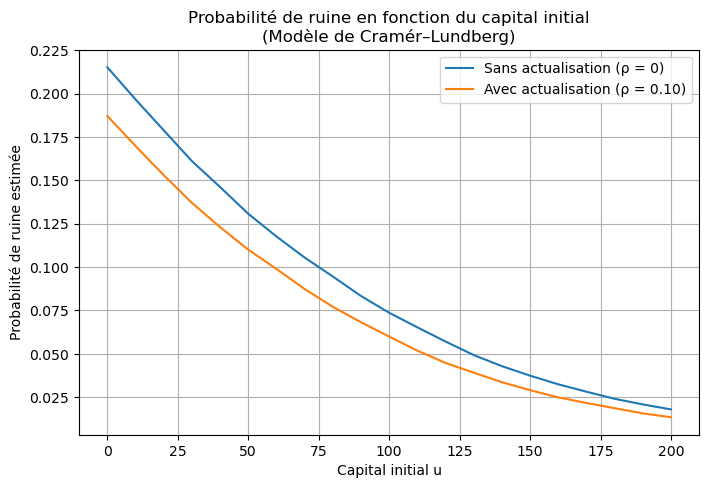

In [201]:
u_tab=np.array([])
p_ruin_tab2=np.array([])
p_ruin_tab1=np.array([])


Liste_R_T_op, Liste_R_T = Simulation_op(rho=0.10)
for i in range(0,21):
    u,p_ruin1 = Monte_Carlo(Liste_R_T,10*i, write = False)
    _,p_ruin2 = Monte_Carlo(Liste_R_T_op,10*i, write = False)
    u_tab=np.append(u_tab,u)
    p_ruin_tab1=np.append(p_ruin_tab1,p_ruin1)
    p_ruin_tab2=np.append(p_ruin_tab2,p_ruin2)


plt.figure(figsize=(8,5))

plt.plot(u_tab, p_ruin_tab1, label="Sans actualisation (ρ = 0)")
plt.plot(u_tab, p_ruin_tab2, label="Avec actualisation (ρ = 0.10)")

plt.xlabel("Capital initial u")
plt.ylabel("Probabilité de ruine estimée")
plt.title("Probabilité de ruine en fonction du capital initial\n(Modèle de Cramér–Lundberg)")

plt.legend()
plt.grid()

plt.show()


### Comparaison des probabilités de ruine

On observe que la probabilité de ruine est plus faible lorsque l’actualisation est introduite. Ce résultat est cohérent, car le facteur d’actualisation réduit le poids des sinistres dans le calcul de la réserve.

Cet effet est d’autant plus marqué que les sinistres sont anciens, puisqu’ils sont davantage atténués par le facteur $e^{-\rho (T - T_i)}$. Ainsi, le modèle avec actualisation conduit à une estimation plus faible du risque de ruine que le modèle classique sans actualisation.

### 2. Mesure du risque : Value at Risk (VaR) 

La Value at Risk (VaR) est une mesure de risque qui quantifie la perte maximale potentielle d’un portefeuille (ou d’une position) sur un horizon de temps donné, pour un niveau de confiance fixé.

Autrement dit, la VaR au niveau de confiance $\alpha$ correspond au seuil de perte $l_\alpha$ tel que :

$$
\mathbb{P}(R > l_\alpha) = 1 - \alpha
$$

où $R$ désigne la perte. Ainsi, avec une probabilité $\alpha$, la perte ne dépasse pas ce seuil.

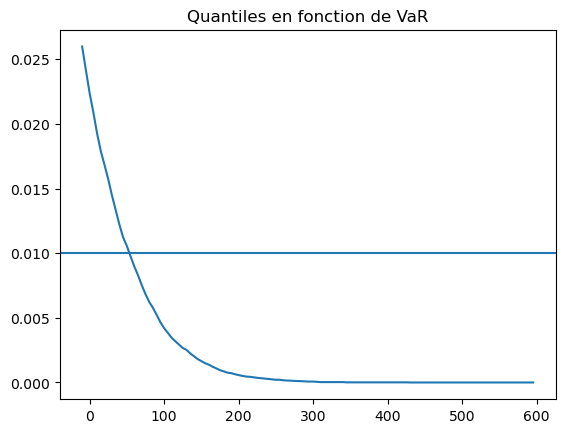

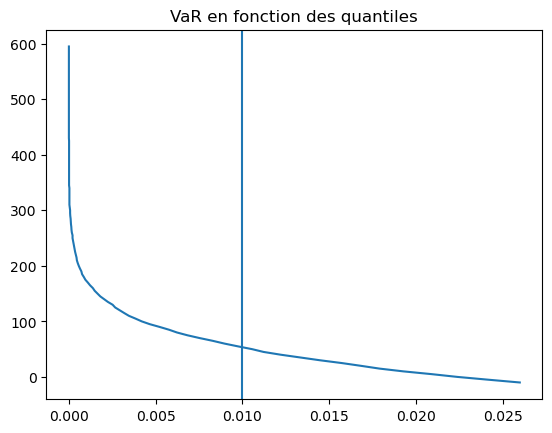

m = 55 and lambda = 0.01


In [202]:
#VaR de R_T
#teta fait beaucoup varier les resultats
teta = 0.10
p_limit=mu*m
p=(1+teta)*p_limit
def find_VaR(R_T,u=0,lam=0.05,graph=True):
    m_range =np.arange(-10,600,5)
    quantiles=np.array([])
    for m in m_range:
        #Find the quantile of m+X associated to the probability 0.05 
        quantile = sum(R_T<-m)/len(R_T)
        quantiles= np.append(quantiles,quantile)
        
    if graph :
        plt.plot(m_range,quantiles)
        plt.title("Quantiles en fonction de VaR")
        plt.axhline(y=lam)
        plt.show()

        plt.plot(quantiles,m_range)
        plt.title("VaR en fonction des quantiles")
        plt.axvline(x=lam)
        plt.show()
        
    for i,m in enumerate(m_range):
        if quantiles[i]<lam:
            return m
    return -1
def generate_R_T(size_MC=100000):
    N_T = np.random.poisson(mu*T,size_MC)
    R_T=np.array([])
    for n in N_T:
        Y=np.random.exponential(1/Beta,n)
        r_T=u+p*T - np.sum(Y)
        R_T=np.append(R_T,r_T)
    return R_T
R_T=generate_R_T()
VaR=find_VaR(R_T,lam=0.01)
print(f"m = {VaR} and lambda = {0.01}")

### Interprétation de la Value at Risk

On obtient une Value at Risk d’environ 55 pour un niveau de probabilité $p = 0{,}01$. Cela signifie que, dans seulement 1\% des cas, la perte dépasse 55 unités (par exemple euros), c’est-à-dire que la réserve passe en dessous de $-55$.

De manière générale, la Value at Risk permet d’estimer les pertes extrêmes susceptibles de se produire avec une probabilité donnée. Elle répond ainsi à la question : *quel niveau de perte peut être atteint avec une probabilité donnée ?*

Enfin, l’évolution de la probabilité de ruine en fonction du seuil $m$ doit décroître rapidement. Dans le cas contraire, cela indiquerait que des pertes importantes (ruines sévères) surviennent avec des probabilités non négligeables, ce qui traduirait un niveau de risque élevé.

## 4. Conclusion

Au cours de ce projet, nous avons étudié le modèle de Cramér–Lundberg, qui permet de modéliser l’évolution de la réserve d’un assureur dans un cadre probabiliste. Cette approche met en évidence l’impact des paramètres du modèle, en particulier le taux de cotisation et l’intensité des sinistres, sur le risque de ruine.

L’analyse théorique a permis d’identifier une condition essentielle de viabilité du modèle, à savoir la nécessité que le taux de cotisation couvre au moins le coût moyen des sinistres. L’étude expérimentale, réalisée à l’aide de simulations de Monte Carlo, a ensuite permis d’estimer la probabilité de ruine et d’analyser son évolution en fonction du capital initial.

Nous avons notamment observé une décroissance exponentielle de la probabilité de ruine en fonction de $u$, ce qui permet d’approximer cette probabilité et d’en déduire un capital initial nécessaire pour atteindre un niveau de risque donné.

L’introduction d’un facteur d’actualisation a permis d’enrichir le modèle en tenant compte de la valeur temporelle de l’argent. Cette extension modifie l’évaluation du risque en réduisant le poids des sinistres anciens, conduisant ainsi à une probabilité de ruine plus faible.

Enfin, l’étude de la Value at Risk (VaR) a permis de compléter l’analyse en apportant une mesure des pertes extrêmes potentielles, offrant ainsi une vision plus globale du risque.

Ce travail met en évidence à la fois l’intérêt et les limites du modèle de Cramér–Lundberg. Bien qu’il repose sur des hypothèses simplificatrices, il constitue une base solide pour l’analyse du risque en assurance et peut être enrichi par des modèles plus complexes afin de mieux refléter la réalité.